# Bayesian Full-Field Inference

The ultimate goal of differentiable forward modeling is **inference**: given an observed weak-lensing map (here a **spin-2 shear** map, in 2 DES Y3 tomographic bins), what are the initial conditions and cosmological parameters that produced it?

This notebook uses the probabilistic modeling layer to:
1. Define the forward model as a NumPyro probabilistic model (IC → LPT → PM → Born → shear)
2. Generate a mock observation and build the likelihood
3. Sample the posterior using MCMC (via `batched_sampling`, MCLMC)
4. Analyze posterior samples

The full-field approach jointly infers the 3D initial conditions field and cosmological parameters, using the differentiable pipeline as the likelihood. *(This demo checks the forward model + trace end-to-end; set `RUN_SAMPLING = True` to actually sample.)*

## Setup

In [1]:
import os

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["JAX_ENABLE_X64"] = "True"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.97"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["--xla_gpu_nccl_termination_timeout_seconds"] = "100"
os.environ["--xla_gpu_executable_warn_stuck_timeout"] = "60"

os.environ["JAX_PLATFORMS"] = "cpu"  # or 'cpu' if you want to run on CPU

import jax

jax.config.update("jax_num_cpu_devices", 4)  # Set this to the number of CPU cores you want to use

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
from jax.sharding import AxisType, NamedSharding
from jax.sharding import PartitionSpec as P
from numpyro.handlers import condition, seed, trace

import jax_fli as jfli

print(f"Number of devices: {jax.device_count()}")
print(f"Devices {jax.devices()}")

jax.config.update("jax_enable_x64", False)

Number of devices: 4
Devices [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]


In [2]:
# 2x2 device mesh. For spin-2 SHEAR maps (shape (n_bins, 2, npix)) the npix axis must go on the mesh,
# NOT the size-2 spin axis: a (4,1) mesh would shard the spin-2 axis over 4 devices (empty shards), and
# (1,4) can't fit the 2 source bins on the bins axis. (2,2) distributes npix x bins cleanly.
if jax.device_count() > 1:
    mesh = jax.make_mesh((4, 1), ("x", "y"), axis_types=(AxisType.Auto, AxisType.Auto))
    sharding = NamedSharding(mesh, P("x", "y"))

    print(f"Mesh shape: {mesh.shape}")
    print(f"Partition spec: {sharding.spec}")
else:
    mesh = None
    sharding = None

    print("No devices available for sharding.")

Mesh shape: OrderedDict({'x': 4, 'y': 1})
Partition spec: P('x', 'y')


## Define Configuration

The `Configurations` dataclass bundles all settings for the forward model and inference:
- Source redshift distributions (`nz_shear`) — here **2 DES Y3 bins**
- Geometry: spherical, `nside`, full-sky box sized to `max_redshift`
- Lensing: `lensing="born"`, `lensing_output="shear"` (spin-2 shear observable)
- Integration / N-body (`t0`, `number_of_shells`, `lpt_order`)
- Cosmological priors and the MCLMC sampler settings

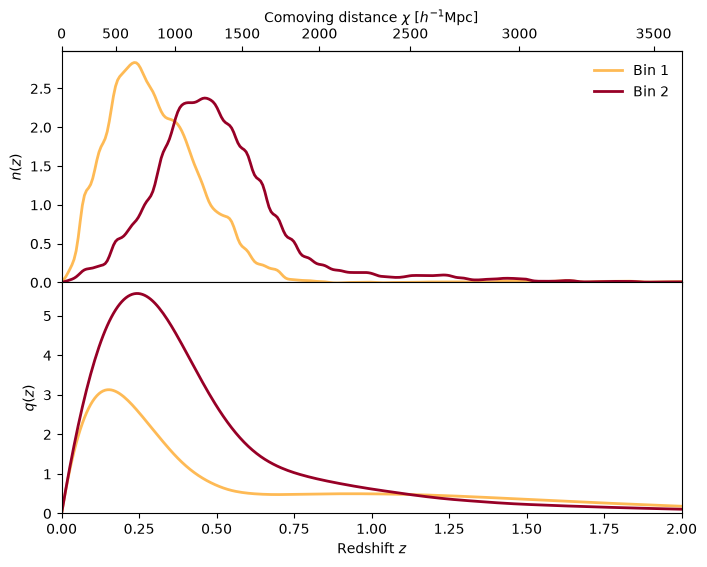

In [3]:
# Source redshift distributions
nz_sources = jfli.io.get_des_y3_nz_shear()[:2]
jfli.data.plot_nz(nz_sources)
plt.show()

In [4]:
priors = {
    "Omega_c": jfli.infer.dist.PreconditionnedUniform(0.1, 0.5),
    "sigma8": jfli.infer.dist.PreconditionnedUniform(0.6, 1.0),
}
sigma_e = 0.3

mesh_size = (16, 16, 16)
nside = 16
paint_nside = 16
halo_size = (4, 4)
observer_position = (0.5, 0.5, 0.5)
max_redshift = 0.7
cosmo = jc.Planck18()

# Full-sky box sized to contain the lightcone out to z=0.7. A centered observer sees the whole sky,
# so the box side = 2 * comoving distance to z=0.7 (see jax_fli.utils.compute_box_size_from_redshift).
box_size = tuple(float(x) for x in jfli.utils.compute_box_size_from_redshift(cosmo, max_redshift, observer_position))
print(f"Full-sky box for z={max_redshift}: {tuple(round(b) for b in box_size)} Mpc/h")


config = jfli.ppl.Configurations(
    # Simulation setting
    mesh_size=mesh_size,
    box_size=box_size,
    halo_size=halo_size,
    nb_steps=30,
    field_sharding=sharding,
    # N-body / force / painting knobs (previously not forwarded from the CLI)
    nbody_solver="BullFrog",
    t0=0.001,
    t1=1.0,
    lpt_order=1,
    number_of_shells=10,
    paint_order="cic",
    gradient_order=4,
    laplace_fd=True,
    shell_spacing="a",
    time_stepping="D",
    min_width=10.0,
    # Lensing
    lensing_output="convergence",
    map2alm_method="jax",  # or jax_cuda
    min_redshift=0.001,
    max_redshift=0.7,
    n_integrate=32,
    # Geometry / painting (spherical only for now)
    nside=nside,
    flatsky_npix=None,
    field_size=None,
    geometry="spherical",
    scheme="rbf_neighbor",
    observer_position=observer_position,
    paint_nside=paint_nside,
    kernel_width_pixels=0.8,
    # Cosmology and nz
    fiducial_cosmology=jc.Planck18,
    nz_shear=nz_sources,
    # Masking / likelihood + observer visibility mask
    log_lightcone=True,
    # Priors and inference settings
    priors=priors,
    sigma_e=sigma_e,
    adjoint="checkpointed",
    checkpoints=5,
    # Sampler settings (BlackJAX NUTS/MCLMC)
    # sampler="MCLMC",
    sampler="NUTS",
    mclmc_desired_energy_var=2e-7,
    mclmc_init_step_size_scale=jnp.sqrt(jnp.prod(jnp.array(mesh_size)) * 1e-5),
    nuts_max_num_doublings=2,
    nuts_target_accept=0.65,
)

Full-sky box for z=0.7: (3490, 3490, 3490) Mpc/h


## Create Initial Field

We create an intial field to check how to use the forward model and inference. We can create it in two ways:

In [5]:
key = jax.random.PRNGKey(42)

init_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
    nside=nside,
    observer_position=observer_position,
    field_sharding=sharding,
)

print(f"Template mesh: {init_field.mesh_size}")
print(f"Template box: {init_field.box_size}")
print(f"Template sharding: {init_field.array.sharding}")

Template mesh: (16, 16, 16)
Template box: (3490.385986328125, 3490.385986328125, 3490.385986328125)
Template sharding: NamedSharding(mesh=Mesh('x': 4, 'y': 1, axis_types=(Auto, Auto)), spec=P('x',), memory_kind=device)


## Build and Test the Forward Model

`make_full_field_model` returns a JIT-compiled function that maps `(cosmology, initial_conditions)` to `(observable, lightcone)`. With `lensing_output="shear"` the observable is a spin-2 shear field of shape `(n_bins, 2, npix)`. We test it with the fiducial cosmology to generate a mock observation.

Mock shear shape: (2, 3072)
Mock lightcone shape: (10, 3072)


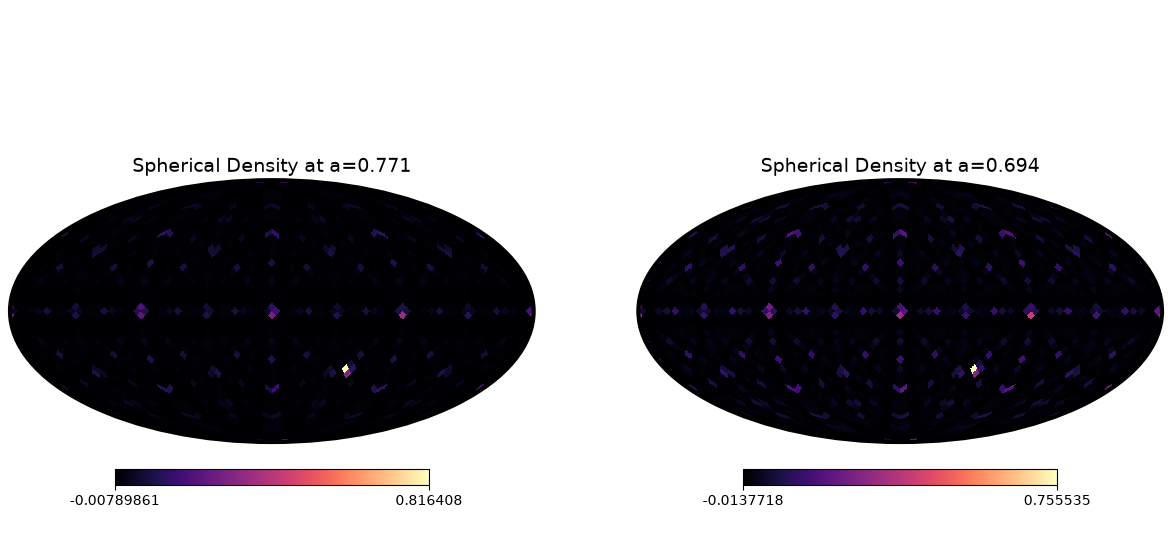

In [6]:
forward_model = jfli.ppl.make_full_field_model(config=config)

# Generate a mock observation (spin-2 shear: shape (n_bins, 2, npix))
observable_mock, lightcone_mock = jax.block_until_ready(forward_model(cosmo, init_field))

print(f"Mock shear shape: {observable_mock.shape}")
print(f"Mock lightcone shape: {lightcone_mock.shape}")
observable_mock.show(ncols=2)

## Build Probabilistic Model

`full_field_probmodel` wraps the forward model in a NumPyro model that:
1. Samples cosmological parameters from the priors
2. Samples the initial conditions from a standard normal
3. Runs the forward model
4. Adds Gaussian noise based on `sigma_e` and galaxy density

In [7]:
prob_model = jfli.ppl.full_field_probmodel(config)

In [8]:
model_trace = trace(seed(prob_model, 0)).get_trace()

omega_c = model_trace["Omega_c"]["value"]
sigma8 = model_trace["sigma8"]["value"]
init_field = model_trace["initial_conditions"]["value"]
# Observable sites are plain arrays (shear: (2, npix) per bin); the IC site is a DensityField.
observables = {f"observable_{i}": model_trace[f"observable_{i}"]["value"] for i in range(len(config.nz_shear))}

print("Sharding of init_field is")
jax.debug.visualize_array_sharding(init_field.array[..., 0])
print("Sharding of observable_0 (shear E/B x npix) is")
jax.debug.visualize_array_sharding(observables["observable_0"])

Sharding of init_field is


                         
          CPU 0          
                         
                         
          CPU 1          
                         
                         
          CPU 2          
                         
                         
          CPU 3          
                         

Sharding of observable_0 (shear E/B x npix) is


  CPU 0    CPU 1    CPU 2    CPU 3  
                                    

In [ ]:
from jax_fli.io import Catalog

init_params = {"Omega_c": omega_c, "sigma8": sigma8, "initial_conditions": init_field}

# Condition on the mock observables (one per source bin — len(nz_shear), NOT number_of_shells).
conditioned_model = condition(
    prob_model,
    data={f"observable_{i}": model_trace[f"observable_{i}"]["value"] for i in range(len(config.nz_shear))},
)
print(f"Omega_c {omega_c} sigma8 {sigma8}")

cosmo = jc.Planck18(Omega_c=omega_c, sigma8=sigma8)
init_field = init_field.replace(z_sources=0.0, density_width=0.0, comoving_centers=0.0, scale_factors=0.0)
Catalog(field=init_field, cosmology=cosmo).to_parquet("truth.parquet")

Omega_c 0.10291754454374313 sigma8 0.6417161822319031


Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

: 

## Sampling with batched_sampling

`batched_sampling` runs MCMC in checkpointed batches. Each batch is saved to disk, allowing long runs to be resumed. It builds the log-density from the NumPyro model and samples it with **BlackJAX**. It supports:
- **Sampler**: `"NUTS"` or `"MCLMC"`
- **Tuning**: NUTS knobs (`max_num_doublings`, `target_accept`) and MCLMC knobs (`mclmc_desired_energy_var`, `mclmc_init_step_size_scale`, ...)
- **Batching**: `batch_count` controls how many batches to run sequentially

For this demo we use a very small number of samples.

In [ ]:
output_path = "output/demo_inference"
sample_key = jax.random.PRNGKey(0)

if mesh is not None:
    jax.set_mesh(mesh)

jfli.infer.batched_sampling(
    conditioned_model,
    # init_params=init_params,
    path=output_path,
    rng_key=sample_key,
    num_warmup=5,
    num_samples=1,
    batch_count=1,
    sampler=config.sampler,  # "NUTS"
    mclmc_desired_energy_var=config.mclmc_desired_energy_var,
    mclmc_init_step_size_scale=config.mclmc_init_step_size_scale,
    max_num_doublings=config.nuts_max_num_doublings,
    target_accept=config.nuts_target_accept,
    progress_bar=True,
    save_callback=jfli.infer.sample2catalog(config),
)

E0624 21:20:17.332862 3878087 rendezvous.cc:116] [id=0] This thread has been waiting for `all to all RendezvousKey{run_id=RunId: -248840362, global_devices=[0, 1, 2, 3], num_local_participants=4, collective_op_kind=cross_module, op_id=88}` for 20 seconds and may be stuck. Expected 4 threads to join the rendezvous, but not all of them arrived on time.
E0624 21:20:17.332904 3878097 rendezvous.cc:116] [id=2] This thread has been waiting for `all to all RendezvousKey{run_id=RunId: -248840362, global_devices=[0, 1, 2, 3], num_local_participants=4, collective_op_kind=cross_module, op_id=88}` for 20 seconds and may be stuck. Expected 4 threads to join the rendezvous, but not all of them arrived on time.
E0624 21:20:17.332912 3878095 rendezvous.cc:116] [id=1] This thread has been waiting for `all to all RendezvousKey{run_id=RunId: -248840362, global_devices=[0, 1, 2, 3], num_local_participants=4, collective_op_kind=cross_module, op_id=88}` for 20 seconds and may be stuck. Expected 4 threads to

In [ ]:
result = jfli.io.extract_catalog(
    set_name="full-field demo",
    cosmo_keys=["Omega_c", "sigma8"],
    patterns=[f"{output_path}/samples"],
    field_statistic=True,
)
print(result)

CatalogExtract(
  name='full-field demo',
  cosmo={'Omega_c': f32[1,1], 'sigma8': f32[1,1]},
  mean_field=DensityField(
    array=f32[1,16,16,16],
    mesh_size=(16, 16, 16),
    box_size=(3490.385986328125, 3490.385986328125, 3490.385986328125),
    z_sources=np.float64(0.0),
    scale_factors=np.float64(0.0),
    comoving_centers=np.float64(0.0),
    density_width=np.float64(0.0),
    observer_position=(0.5, 0.5, 0.5),
    halo_size=(4, 4),
    nside=16,
    status=<FieldStatus.INITIAL_FIELD: '2'>,
    unit=<DensityUnit.DENSITY: '2'>,
    name=np.str_('initial_conditions_batch_0')
  ),
  std_field=DensityField(
    array=f32[1,16,16,16],
    mesh_size=(16, 16, 16),
    box_size=(3490.385986328125, 3490.385986328125, 3490.385986328125),
    z_sources=np.float64(0.0),
    scale_factors=np.float64(0.0),
    comoving_centers=np.float64(0.0),
    density_width=np.float64(0.0),
    observer_position=(0.5, 0.5, 0.5),
    halo_size=(4, 4),
    nside=16,
    status=<FieldStatus.INITIAL_FIELD:

ValueError: cannot convert float NaN to integer

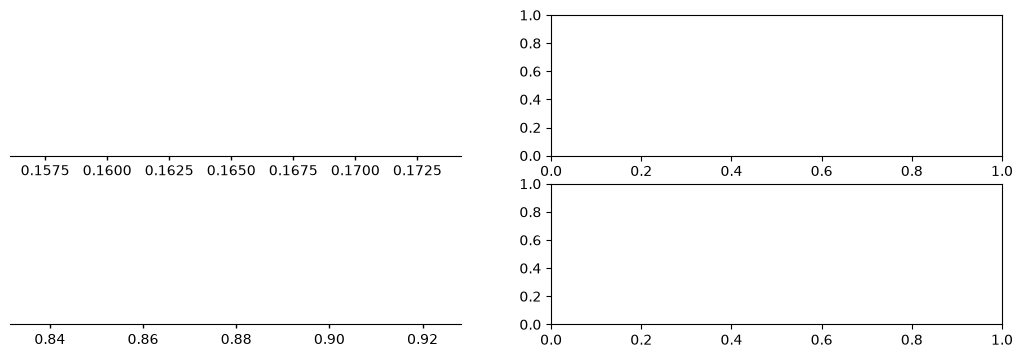

In [ ]:
# Diagnostics (ArviZ rank/trace + summary.md, field projections) and the GetDist triangle plot.
jfli.infer.analyze(result, "output/demo_report")
jfli.infer.plot_posterior(
    result,
    outpath="output/demo_report/posterior.png",
    labels={"Omega_c": r"\Omega_c", "sigma8": r"\sigma_8"},
)